# Miami Real Estate — Análisis Exploratorio de Datos (EDA)

**Dataset:** Miami / South Florida Residential Property Sales  
**Objetivo:** Predecir el precio de venta ajustado por HPI (`lastSoldPrice_hpi_adjusted`) a partir de datos tabulares, texto e imágenes.

**Target:**
- `lastSoldPrice_hpi_adjusted` — Precio de venta ajustado por Housing Price Index (dólares)
- `log_price` — `log1p(lastSoldPrice_hpi_adjusted)` — escala recomendada para entrenar

## Descripción de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| `zpid` | str | ID único |
| `lastSoldPrice_hpi_adjusted` | float | **Target**: precio de venta ajustado HPI |
| `log_price` | float | log1p del target |
| `bedrooms` | int | Habitaciones |
| `bathrooms` | float | Baños |
| `livingArea` | float | Área habitable (pies²) |
| `yearBuilt` | float | Año de construcción |
| `latitude/longitude` | float | Ubicación |
| `lotAreaValue` | float | Tamaño del lote (pies²) |
| `photoCount` | int | Fotos del listado |
| `homeType` | str | Tipo de propiedad |
| `zipcode` | str | Código postal |
| `taxAssessedValue` | float | Valor catastral |
| `last_listing_price` | float | Precio de listado |
| `has_hoa/has_pool/has_garage/has_waterfront` | bool | Atributos |
| `tag_price_cut/tag_new_construction/tag_foreclosure` | bool | Tags |
| `avg_school_rating` | float | Rating escuelas cercanas |
| `desc_length/desc_word_count` | int | Métricas de texto |
| `desc_is_boilerplate/desc_mentions_*` | bool | Features de texto |

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = [12.0, 6.0]
sns.set_style('whitegrid')

## 2. Carga de Datos

In [2]:
train = pd.read_csv('../../data/tabular/train_processed.csv')
test  = pd.read_csv('../../data/tabular/test_processed.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')

Train shape : (11840, 46)
Test  shape : (5038, 44)


## 3. Exploración Inicial

In [ ]:
train.head()

In [ ]:
train.info()

In [ ]:
train.describe()

### 3.1 Valores Nulos

In [ ]:
nulos = train.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print('Columnas con valores nulos:')
print(nulos)
print(f'\nPorcentaje sobre {len(train)} filas:')
print((nulos / len(train) * 100).round(2))

if len(nulos) > 0:
    nulos.plot(kind='bar', color='steelblue')
    plt.title('Valores nulos por columna')
    plt.ylabel('Cantidad')
    plt.tight_layout()
    plt.show()
else:
    print('Sin valores nulos.')

## 4. Variable Target: Precio de Venta

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['lastSoldPrice_hpi_adjusted'].plot(kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_title('Distribución del Precio de Venta')
axes[0].set_xlabel('Precio (USD)')

train['log_price'].plot(kind='hist', bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribución de log_price')
axes[1].set_xlabel('log_price')

plt.tight_layout()
plt.show()

print(f"Media   : ${train['lastSoldPrice_hpi_adjusted'].mean():,.0f}")
print(f"Mediana : ${train['lastSoldPrice_hpi_adjusted'].median():,.0f}")
print(f"Mínimo  : ${train['lastSoldPrice_hpi_adjusted'].min():,.0f}")
print(f"Máximo  : ${train['lastSoldPrice_hpi_adjusted'].max():,.0f}")

In [ ]:
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
perc_vals = np.percentile(train['lastSoldPrice_hpi_adjusted'].dropna(), percentiles)
pd.DataFrame({'Percentil': percentiles, 'Precio': [f'${v:,.0f}' for v in perc_vals]})

## 5. Tipo de Propiedad (homeType)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['homeType'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Cantidad por Tipo')
axes[0].tick_params(axis='x', rotation=30)

ht_price = train.groupby('homeType')['lastSoldPrice_hpi_adjusted'].median().sort_values()
ht_price.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio Mediano por Tipo')

plt.tight_layout()
plt.show()

In [ ]:
order = train.groupby('homeType')['lastSoldPrice_hpi_adjusted'].median().sort_values().index
plt.figure(figsize=(12, 5))
sns.boxplot(x='homeType', y='lastSoldPrice_hpi_adjusted', data=train, order=order, palette='Set2')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.title('Precio por Tipo de Propiedad (escala log)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Variables Numéricas

### 6.1 Habitaciones y Baños

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['bedrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Habitaciones')
axes[0].tick_params(axis='x', rotation=0)

bed_price = train.groupby('bedrooms')['lastSoldPrice_hpi_adjusted'].median()
bed_price[bed_price.index <= 10].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio Mediano por Habitaciones')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 6.2 Área Habitable (livingArea)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['livingArea'].plot(kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Área Habitable (pies²)')

axes[1].scatter(train['livingArea'], train['lastSoldPrice_hpi_adjusted'], alpha=0.1, s=5, color='steelblue')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio vs Área Habitable')
axes[1].set_xlim(0, 10000)

plt.tight_layout()
plt.show()

### 6.3 Año de Construcción

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['yearBuilt'].dropna().plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Año de Construcción')

train['decade'] = (train['yearBuilt'] // 10 * 10).astype('Int64')
decade_price = train.groupby('decade')['lastSoldPrice_hpi_adjusted'].median().dropna()
decade_price.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio Mediano por Década')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6.4 Fotos del Listado (photoCount)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['photoCount'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Cantidad de Fotos')

train['photo_group'] = pd.cut(train['photoCount'], bins=[0,5,10,15,20,30,100],
                               labels=['1-5','6-10','11-15','16-20','21-30','30+'])
photo_price = train.groupby('photo_group', observed=True)['lastSoldPrice_hpi_adjusted'].median()
photo_price.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio Mediano por Rango de Fotos')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 6.5 Variables Fiscales: taxAssessedValue y last_listing_price

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mask = train['taxAssessedValue'].notna() & (train['taxAssessedValue'] < 5e6)
axes[0].scatter(train.loc[mask,'taxAssessedValue'], train.loc[mask,'lastSoldPrice_hpi_adjusted'],
                alpha=0.1, s=5, color='steelblue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].set_title('Precio vs Valor Catastral')

mask2 = train['last_listing_price'].notna() & (train['last_listing_price'] < 5e6)
axes[1].scatter(train.loc[mask2,'last_listing_price'], train.loc[mask2,'lastSoldPrice_hpi_adjusted'],
                alpha=0.1, s=5, color='coral')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio vs Precio de Listado')

plt.tight_layout()
plt.show()

### 6.6 Rating de Escuelas Cercanas

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mask = train['avg_school_rating'].notna()
axes[0].scatter(train.loc[mask,'avg_school_rating'], train.loc[mask,'lastSoldPrice_hpi_adjusted'],
                alpha=0.1, s=5, color='steelblue')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].set_title('Precio vs Rating de Escuelas')

train['school_group'] = pd.cut(train['avg_school_rating'].dropna(),
                                bins=[0,2,4,6,8,10], labels=['0-2','2-4','4-6','6-8','8-10'])
school_price = train.groupby('school_group', observed=True)['lastSoldPrice_hpi_adjusted'].median()
school_price.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio Mediano por Rating de Escuelas')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. Variables Booleanas

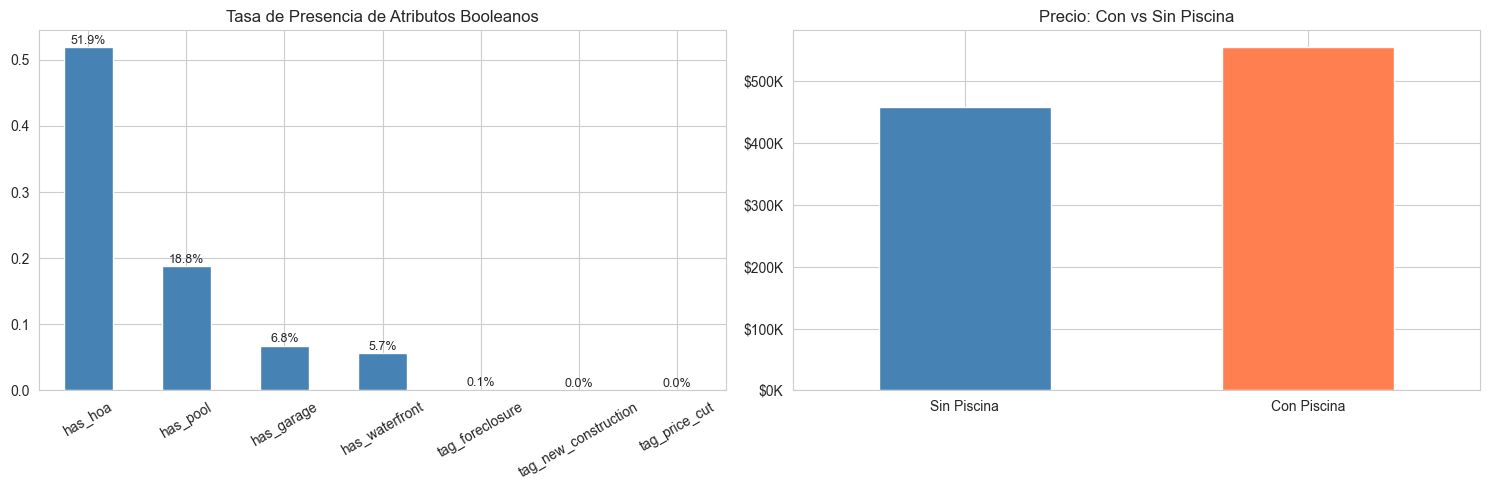

In [3]:
bool_cols = ['has_hoa','has_pool','has_garage','has_waterfront',
             'tag_price_cut','tag_new_construction','tag_foreclosure']

bool_rates = train[bool_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bool_rates.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Tasa de Presencia de Atributos Booleanos')
axes[0].tick_params(axis='x', rotation=30)
for i,v in enumerate(bool_rates):
    axes[0].text(i, v+0.005, f'{v:.1%}', ha='center', fontsize=9)

pool_price = train.groupby('has_pool')['lastSoldPrice_hpi_adjusted'].median()
pool_price.index = ['Sin Piscina','Con Piscina']
pool_price.plot(kind='bar', ax=axes[1], color=['steelblue','coral'], edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio: Con vs Sin Piscina')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

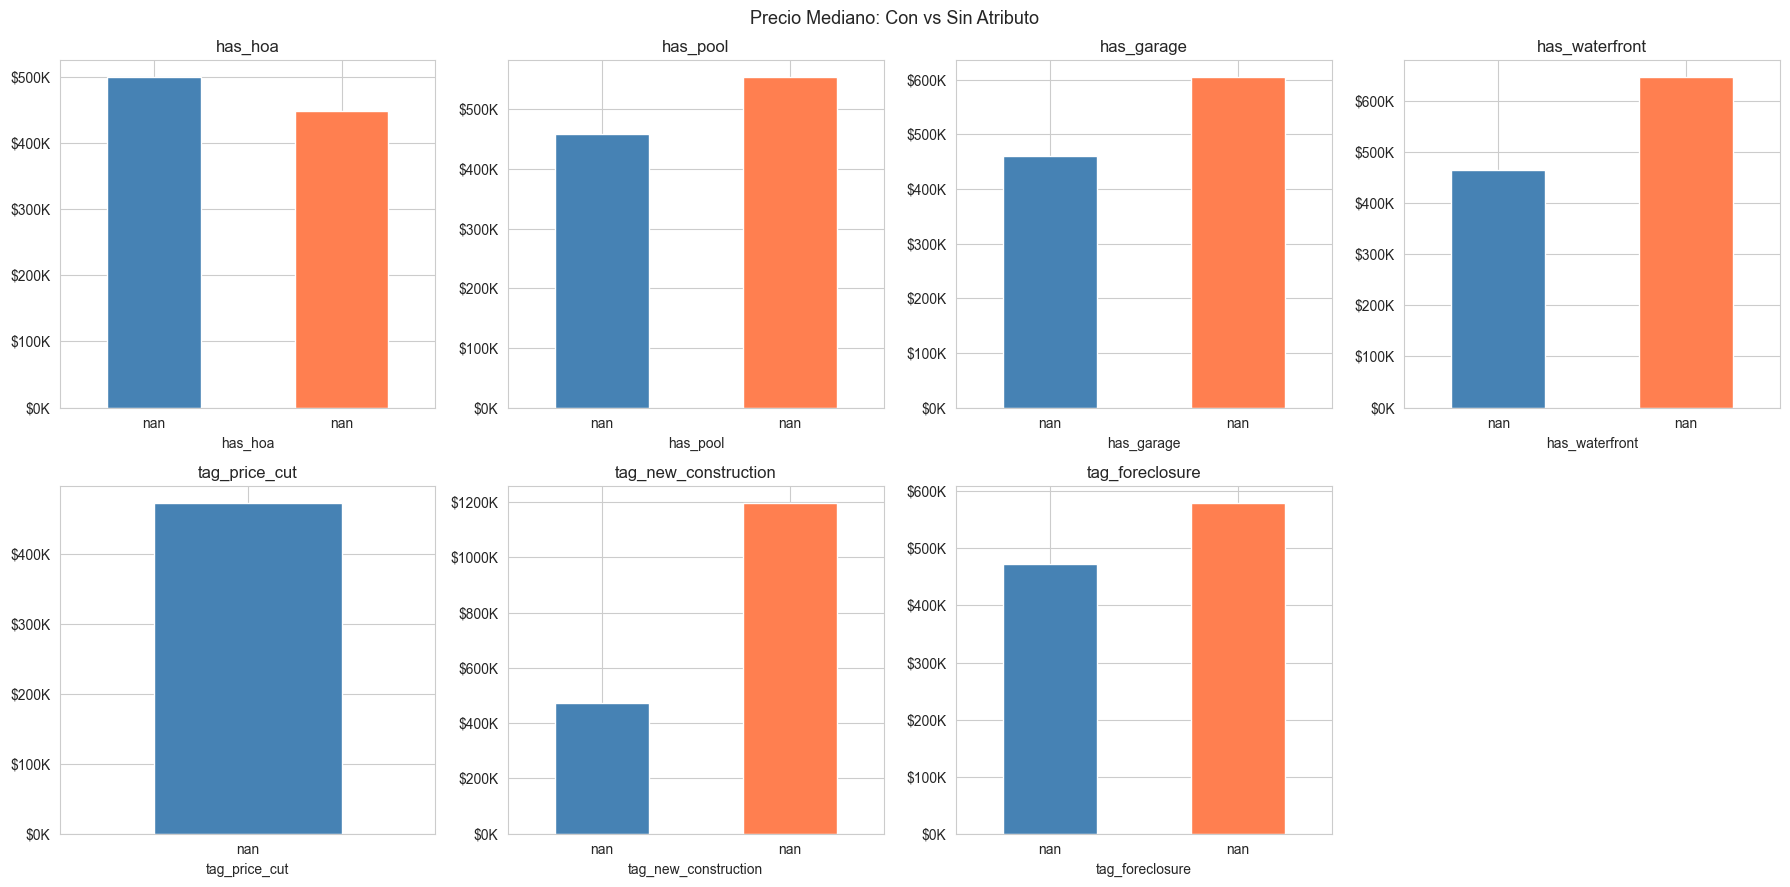

In [4]:
bool_cols = ['has_hoa','has_pool','has_garage','has_waterfront',
             'tag_price_cut','tag_new_construction','tag_foreclosure']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

label_map = {False: 'No', True: 'Sí', 0: 'No', 1: 'Sí'}

for i, col in enumerate(bool_cols):
    g = train.groupby(col)['lastSoldPrice_hpi_adjusted'].median()
    g.index = g.index.map(label_map)
    colors = ['steelblue', 'coral'][:len(g)]
    g.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)
plt.suptitle('Precio Mediano: Con vs Sin Atributo', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Análisis Geográfico

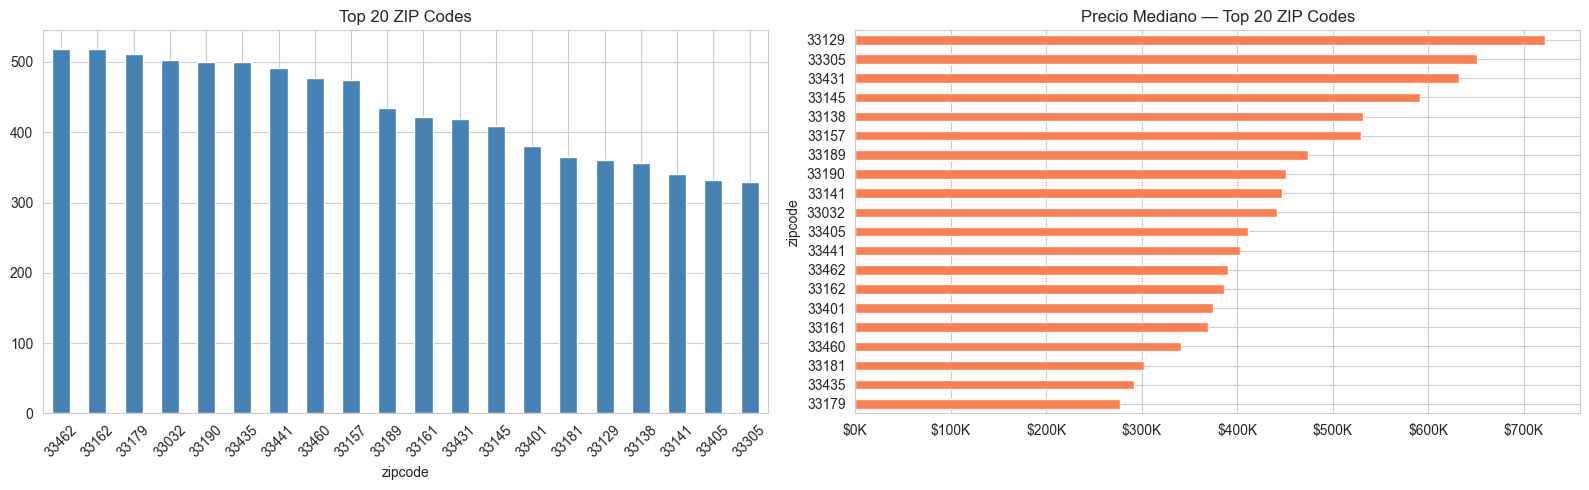

In [5]:
top_zips = train['zipcode'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_zips.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 ZIP Codes')
axes[0].tick_params(axis='x', rotation=45)

zip_price = train.groupby('zipcode')['lastSoldPrice_hpi_adjusted'].median()
zip_price.loc[top_zips.index].sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio Mediano — Top 20 ZIP Codes')

plt.tight_layout()
plt.show()

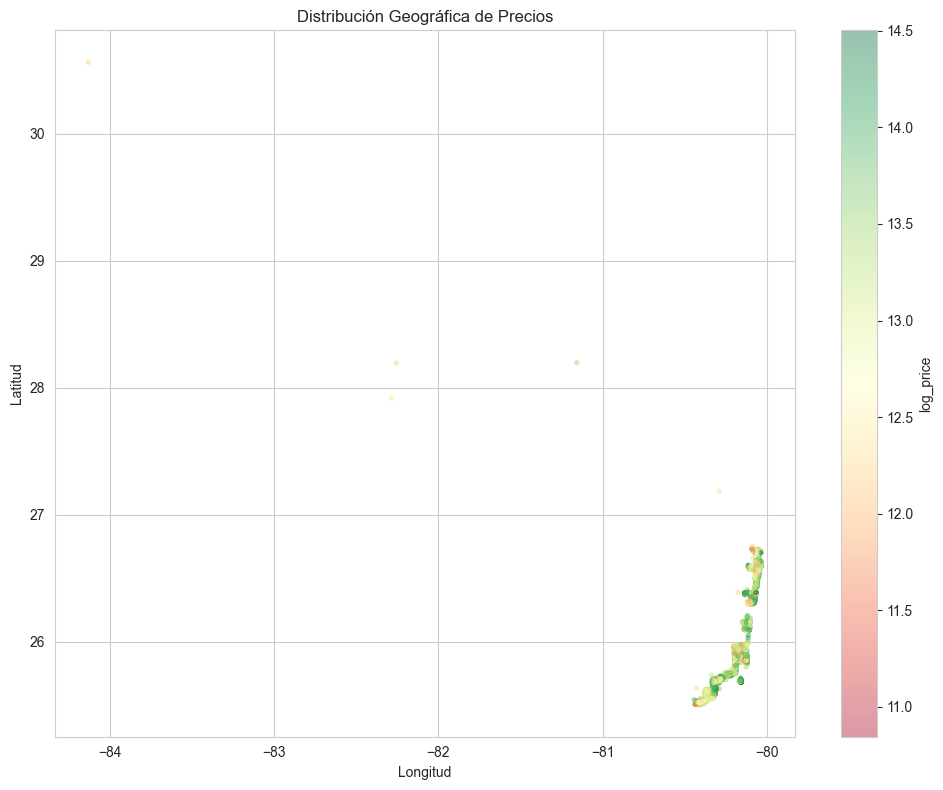

In [6]:
sample = train.dropna(subset=['latitude','longitude','lastSoldPrice_hpi_adjusted'])\
               .sample(min(5000,len(train)), random_state=42)

plt.figure(figsize=(10, 8))
sc = plt.scatter(sample['longitude'], sample['latitude'],
                 c=np.log1p(sample['lastSoldPrice_hpi_adjusted']),
                 cmap='RdYlGn', alpha=0.4, s=8)
plt.colorbar(sc, label='log_price')
plt.title('Distribución Geográfica de Precios')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.tight_layout()
plt.show()

## 9. Matriz de Correlación

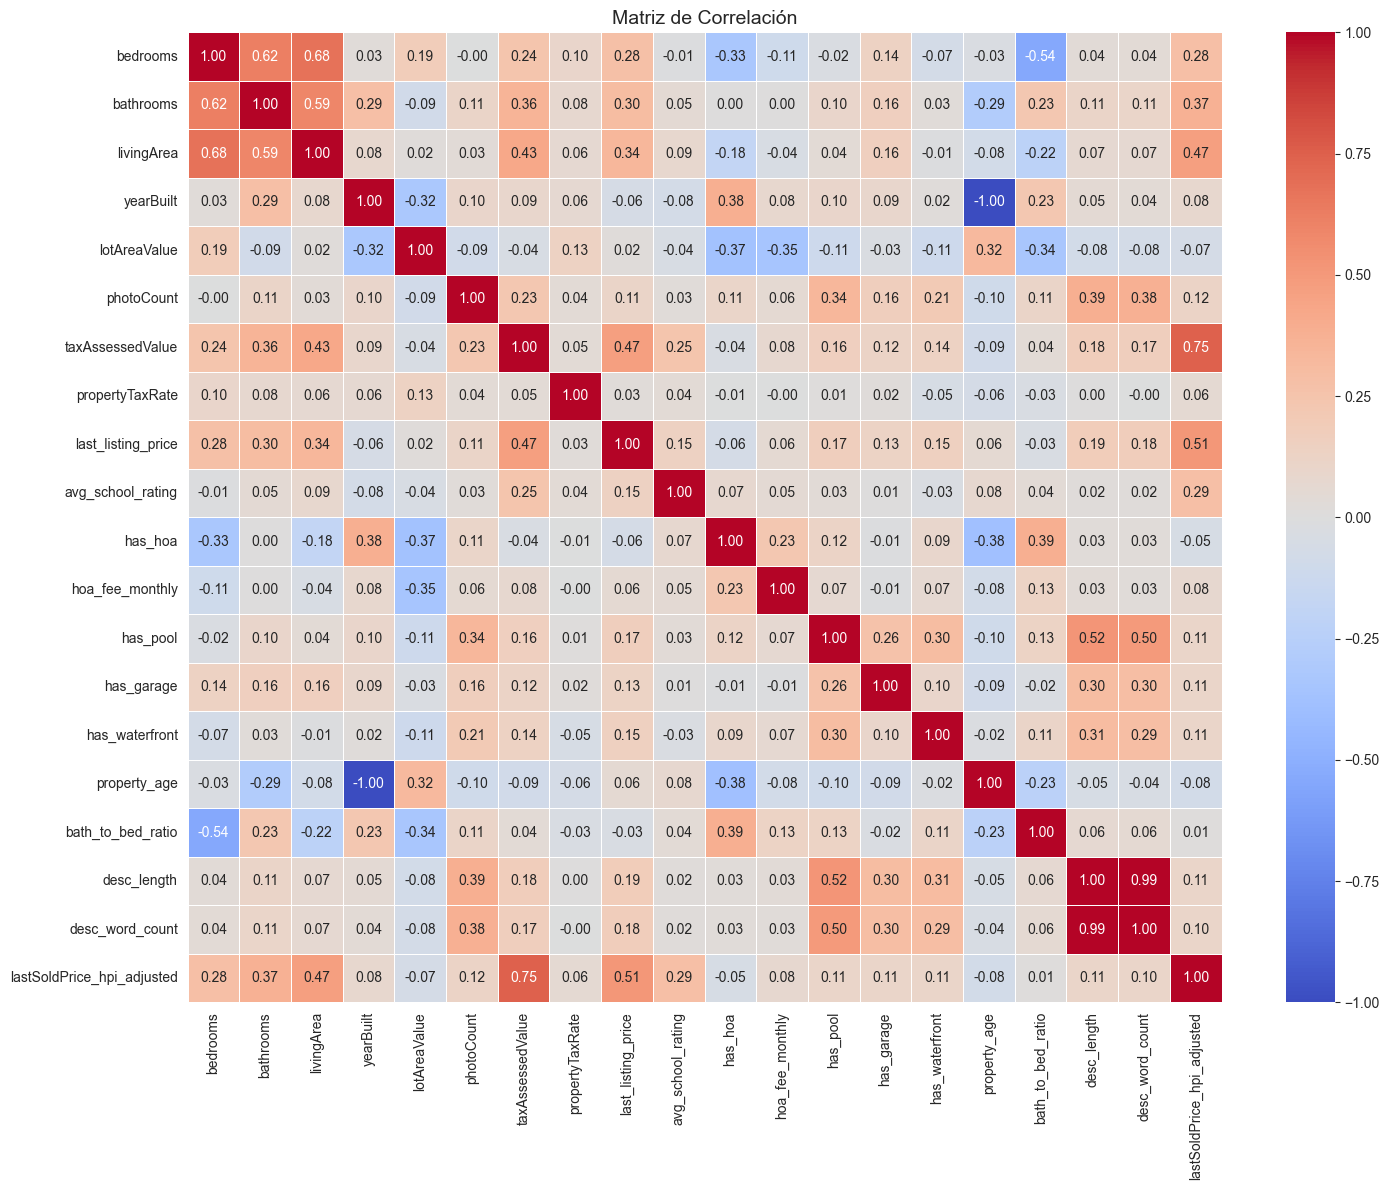

In [7]:
num_cols = ['bedrooms','bathrooms','livingArea','yearBuilt','lotAreaValue',
            'photoCount','taxAssessedValue','propertyTaxRate','last_listing_price',
            'avg_school_rating','has_hoa','hoa_fee_monthly','has_pool',
            'has_garage','has_waterfront','property_age','bath_to_bed_ratio',
            'desc_length','desc_word_count','lastSoldPrice_hpi_adjusted']

corr = train[num_cols].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
price_corr = corr['lastSoldPrice_hpi_adjusted'].drop('lastSoldPrice_hpi_adjusted')\
                   .sort_values(key=abs, ascending=False)
print('Top correlaciones con el precio:')
print(price_corr.round(3).to_string())

Top correlaciones con el precio:
taxAssessedValue      0.748
last_listing_price    0.508
livingArea            0.470
bathrooms             0.374
avg_school_rating     0.288
bedrooms              0.282
photoCount            0.124
desc_length           0.109
has_waterfront        0.107
has_garage            0.106
has_pool              0.106
desc_word_count       0.104
property_age         -0.084
yearBuilt             0.084
hoa_fee_monthly       0.076
lotAreaValue         -0.068
propertyTaxRate       0.059
has_hoa              -0.053
bath_to_bed_ratio     0.013


## 10. Análisis Bivariado por Tipo de Propiedad

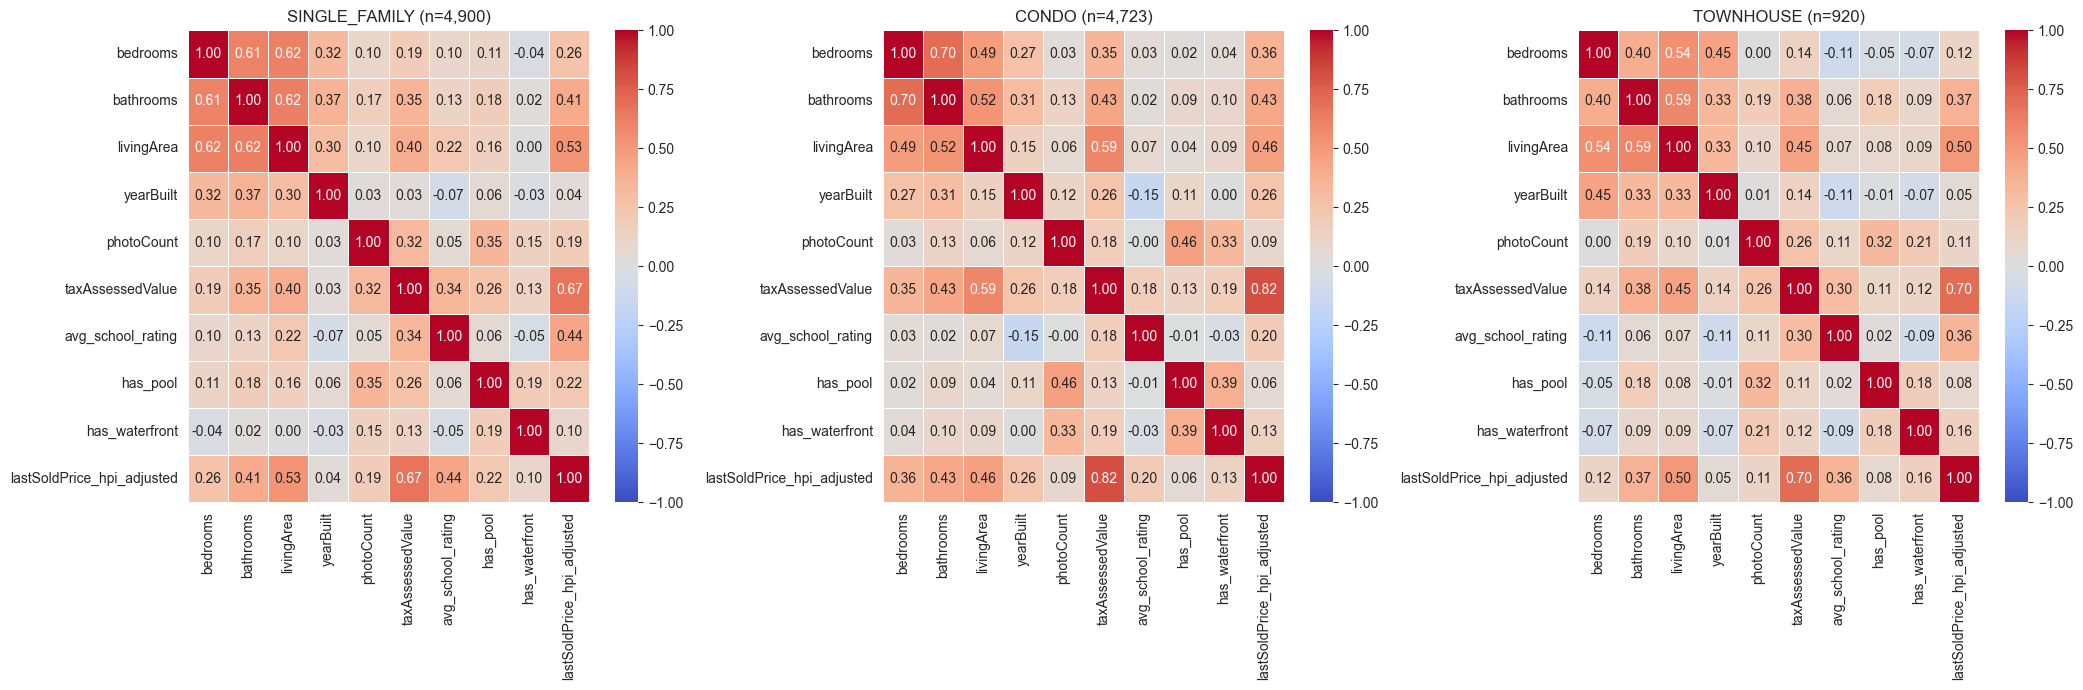

In [9]:
main_types = train['homeType'].value_counts().head(3).index.tolist()

corr_cols = ['bedrooms','bathrooms','livingArea','yearBuilt','photoCount',
             'taxAssessedValue','avg_school_rating','has_pool','has_waterfront',
             'lastSoldPrice_hpi_adjusted']

fig, axes = plt.subplots(1, len(main_types), figsize=(7*len(main_types), 7))
if len(main_types) == 1: axes = [axes]

for ax, ht in zip(axes, main_types):
    subset = train[train['homeType'] == ht]
    sns.heatmap(subset[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'{ht} (n={len(subset):,})', fontsize=12)

plt.tight_layout()
plt.show()

## 11. Análisis de Texto: Description

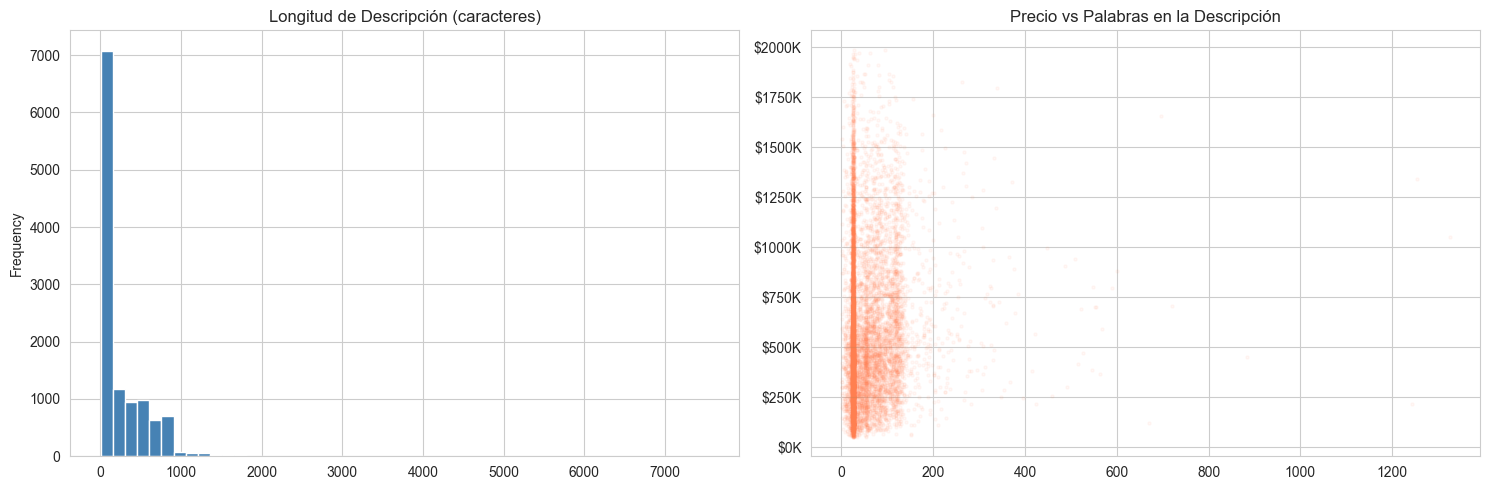

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['desc_length'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Longitud de Descripción (caracteres)')

axes[1].scatter(train['desc_word_count'], train['lastSoldPrice_hpi_adjusted'],
                alpha=0.05, s=5, color='coral')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio vs Palabras en la Descripción')

plt.tight_layout()
plt.show()

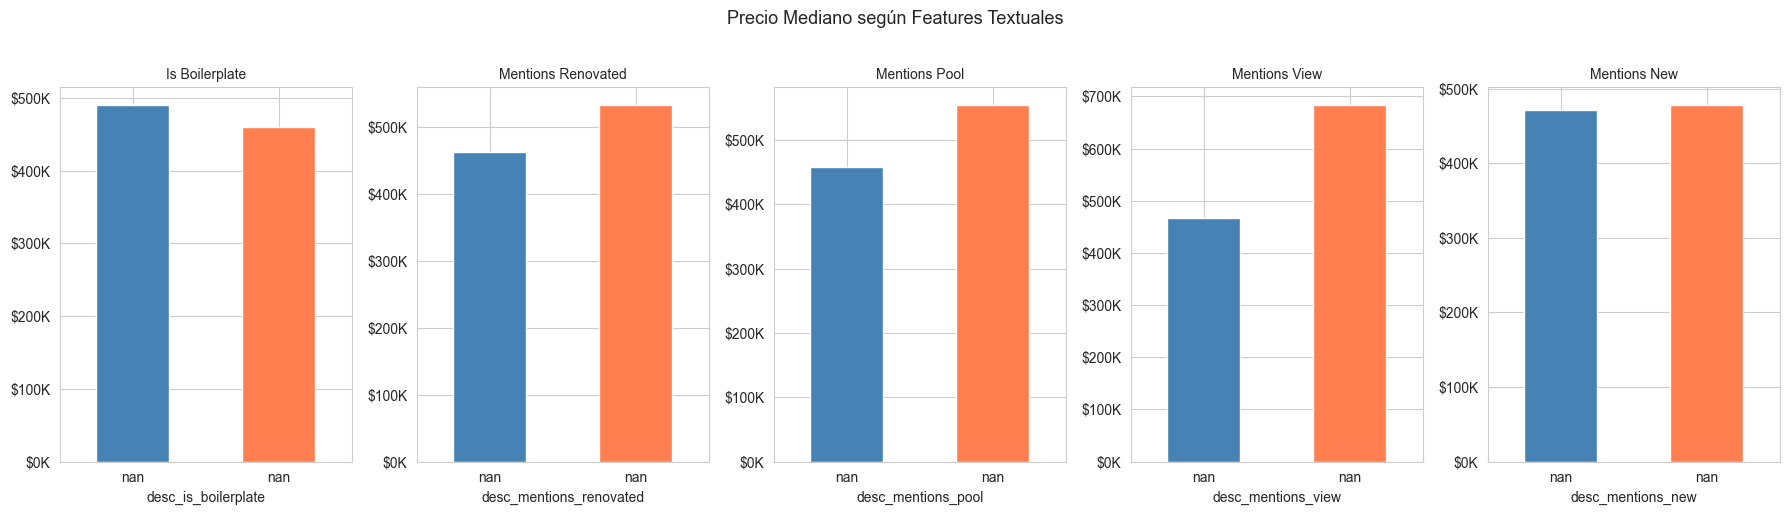

In [11]:
text_cols = ['desc_is_boilerplate','desc_mentions_renovated',
             'desc_mentions_pool','desc_mentions_view','desc_mentions_new']

label_map = {False: 'No', True: 'Sí', 0: 'No', 1: 'Sí'}

fig, axes = plt.subplots(1, len(text_cols), figsize=(18, 5))

for ax, col in zip(axes, text_cols):
    g = train.groupby(col)['lastSoldPrice_hpi_adjusted'].median()
    g.index = g.index.map(label_map)
    colors = ['steelblue', 'coral'][:len(g)]
    g.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
    ax.set_title(col.replace('desc_','').replace('_',' ').title(), fontsize=10)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Precio Mediano según Features Textuales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. HOA Fee

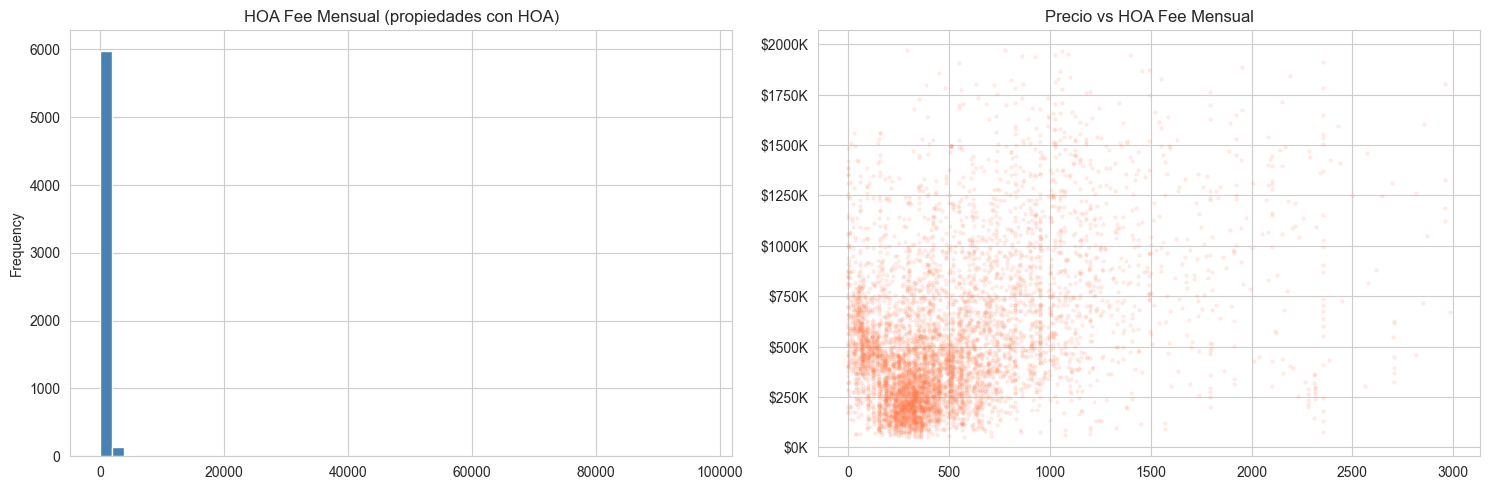

Prop. con HOA: 51.9%
HOA fee mediano: $400/mes


In [12]:
hoa_data = train[train['has_hoa'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hoa_data['hoa_fee_monthly'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('HOA Fee Mensual (propiedades con HOA)')

mask = hoa_data['hoa_fee_monthly'] < 3000
axes[1].scatter(hoa_data.loc[mask,'hoa_fee_monthly'], hoa_data.loc[mask,'lastSoldPrice_hpi_adjusted'],
                alpha=0.1, s=5, color='coral')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio vs HOA Fee Mensual')

plt.tight_layout()
plt.show()

print(f"Prop. con HOA: {train['has_hoa'].mean():.1%}")
print(f"HOA fee mediano: ${hoa_data['hoa_fee_monthly'].median():,.0f}/mes")

## 13. Conclusiones del EDA

El análisis exploratorio sobre el dataset de propiedades residenciales de Miami / Sur de Florida (11,840 registros de train) permite extraer las siguientes conclusiones:

**Target:** La distribución del precio de venta es fuertemente asimétrica a la derecha. Entrenar en escala logarítmica (`log_price`) es la estrategia correcta.

**Tipo de propiedad:** `homeType` es altamente informativa. SINGLE_FAMILY y MULTI_FAMILY son los tipos más caros, mientras CONDO concentra la mayor cantidad de registros.

**Variables numéricas clave:** `livingArea`, `bedrooms`, `bathrooms` tienen correlación positiva esperada. `taxAssessedValue` y `last_listing_price` correlacionan fuertemente con el precio (posible leakage). `yearBuilt` muestra patrón no lineal.

**Geografía:** Alta variabilidad de precios entre ZIP codes. Latitud/longitud capturan señal geográfica útil.

**Atributos booleanos:** `has_waterfront` y `has_pool` se asocian a precios más altos. `tag_foreclosure` se asocia a precios más bajos (vendedores en apuros, como describe la mecánica de la competencia).

**Escuelas:** `avg_school_rating` muestra correlación positiva pero con alta dispersión.

**Texto:** `desc_mentions_view` y `desc_mentions_renovated` muestran diferencias de precio mediano relevantes. `desc_is_boilerplate` (~52%) puede ser útil como señal de calidad del listado.

**Variables clave para el modelo:** `livingArea`, `taxAssessedValue`, `last_listing_price`, `homeType`, `zipcode`, `has_waterfront`, `has_pool`, `avg_school_rating`, `yearBuilt`, `bedrooms`, `bathrooms`, coordenadas geográficas, y features derivados del texto. Un modelo multimodal con embeddings de imágenes/texto puede agregar señal adicional significativa.